# 파이썬 30회차 기출문제 해답


## 문제 1

**Data description**

개인의 건강 상태를 평가하기 위한 다양한 생물학적 및 생리학적 지표들을 포함하는 건강 검진 데이터입니다.

-   **Age**: 피검자의 나이

-   **Gender**: 피검자의 성별

-   **BMI**: 체질량 지수

-   **FPG**: 공복 시 혈당 수치

-   **Chol**: 혈중 총 콜레스테롤 수치

-   **Tri**: 혈중 트리글리세라이드 수치

-   **HDL**: 혈중 고밀도지단백 콜레스테롤 수치 (High-Density Lipoprotein Cholesterol)

-   **LDL**: 혈중 저밀도지단백 콜레스테롤 수치 (Low-Density Lipoprotein Cholesterol)

-   **ALT**: 간 효소 수치 중 하나로, 알라닌 아미노트랜스페라제 (Alanine Aminotransferase)

-   **DBP**: 이완기 혈압 수치 (Diastolic Blood Pressure)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [21]:
dt1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/30/problem1.csv')
display(dt1.info())
display(dt1.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     4303 non-null   int64  
 1   Gender  4303 non-null   int64  
 2   BMI     4303 non-null   float64
 3   DBP     4303 non-null   int64  
 4   FPG     4303 non-null   float64
 5   Chol    4302 non-null   float64
 6   Tri     4303 non-null   float64
 7   HDL     4303 non-null   float64
 8   LDL     4303 non-null   float64
 9   ALT     4303 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 336.3 KB


None

,Age,Gender,BMI,DBP,FPG,Chol,Tri,HDL,LDL,ALT
0,26,1,20.1,81,5.8,4.36,0.86,0.90,2.43,12.0
1,40,1,17.7,54,4.6,3.70,1.02,1.50,2.04,9.2
2,40,2,19.7,53,5.3,5.87,1.29,1.75,3.37,10.1


In [22]:
dt1.columns

Index(['Age', 'Gender', 'BMI', 'DBP', 'FPG', 'Chol', 'Tri', 'HDL', 'LDL',
       'ALT'],
      dtype='object')

1.  **EDA를 수행하시오.**

<데이터의 변수>
- 범주형 변수: Gender
- 수치형 변수: 'Age', 'BMI', 'DBP', 'FPG', 'Chol', 'Tri', 'HDL', 'LDL', 'ALT'  
  * Age를 제외하고는 모두 연속형 변수임.

In [23]:
# 카테고리 변수 변환: Gender
dt1['Gender'] = dt1['Gender'].astype('category')

In [24]:
print("각 컬럼별 결측치 확인")
display(dt1.isna().sum())

display(dt1[dt1['Chol'].isna() == True])

각 컬럼별 결측치 확인


Age       0
Gender    0
BMI       0
DBP       0
FPG       0
Chol      1
Tri       0
HDL       0
LDL       0
ALT       0
dtype: int64

,Age,Gender,BMI,DBP,FPG,Chol,Tri,HDL,LDL,ALT
10,51,1,22.0,84,4.61,NaN,2.4,1.07,2.95,15.5


`chol` 칼럼에 결측치가 1개(0.02%) 존재함. 결측률이 높지 않아 분석에 큰 영향을 주지 않을 것이므로 삭제한다.

In [25]:
dt1 = dt1.dropna()

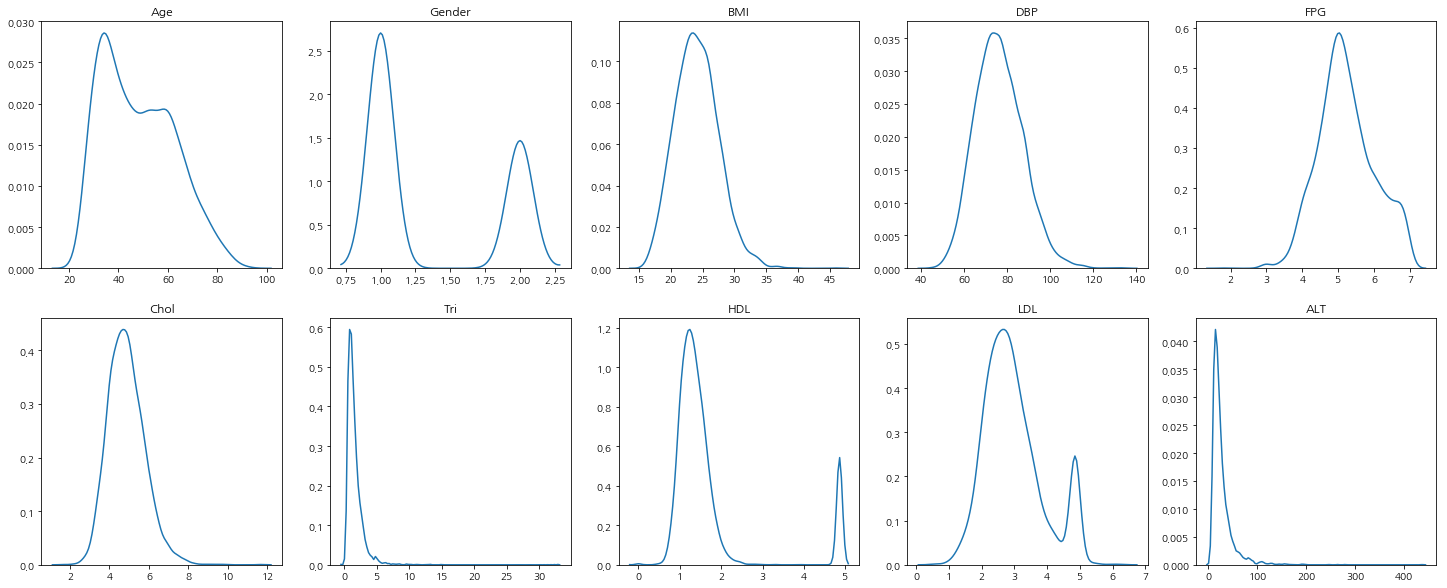

In [26]:
fig, ax = plt.subplots(2, 5, figsize=(25, 10))

for i, col in enumerate(dt1.columns):
    x = i // 5
    y = i % 5
    sns.kdeplot(data=dt1[col], ax=ax[x, y], legend=None)
    ax[x, y].set_title(col)
plt.show()

In [27]:
print("<수치형 변수의 통계량>")
display(dt1.describe().T)
print("<범주형 변수의 통계량>")
display(dt1.describe(include='category'))

<수치형 변수의 통계량>


,count,mean,std,min,25%,50%,75%,max
Age,4302.0,48.084379,14.687795,22.00,35.00,46.00,59.000,93.000000
BMI,4302.0,24.124417,3.397535,15.60,21.70,24.00,26.300,45.800000
DBP,4302.0,76.358670,11.004719,45.00,69.00,76.00,83.000,134.000000
FPG,4302.0,5.226511,0.781124,1.78,4.70,5.14,5.700,6.990000
Chol,4302.0,4.860732,0.925484,1.65,4.20,4.79,5.430,11.650000
Tri,4302.0,1.588287,1.260088,0.00,0.86,1.28,1.940,32.640000
HDL,4302.0,1.666904,1.079464,0.00,1.13,1.34,1.610,4.860753
LDL,4302.0,2.976227,0.892300,0.54,2.35,2.82,3.420,6.270000
ALT,4302.0,26.757426,22.281851,4.50,14.30,20.50,31.075,436.200000


<범주형 변수의 통계량>


,Gender
count,4302
unique,2
top,1
freq,2789


각 변수의 분포를 확인한다. 통계량은 위와 같다. 
- Age는 20~40대 사이가 차지하는 비율이 높으며, 왼쪽으로 치우친 형태이다.
- Gender는 남성의 비율이 여성보다 훨씬 많다.(남성: 1, 여성: 2)
- HDL, LDL은 이봉 분포를 보이고 있다.
- BMI, DBP, Chol, Tri, LDL, ALT 는 왼쪽으로 치우치며 오른쪽으로 꼬리가 긴 분포를 보이고 있다.
- Tri, ALT는 첨도가 높으며, 특정값에 분포가 집중되어 있다.

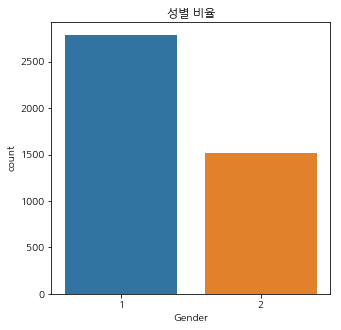

In [28]:
plt.figure(figsize=(5, 5))
sns.countplot(dt1['Gender'])
plt.title('성별 비율')
plt.show()

In [29]:
dt1['Gender'].value_counts(normalize=True)

1    0.648303
2    0.351697
Name: Gender, dtype: float64

데이터 중 남성의 비율이 약 65%로, 여성(35%)에 비해 훨씬 높다.

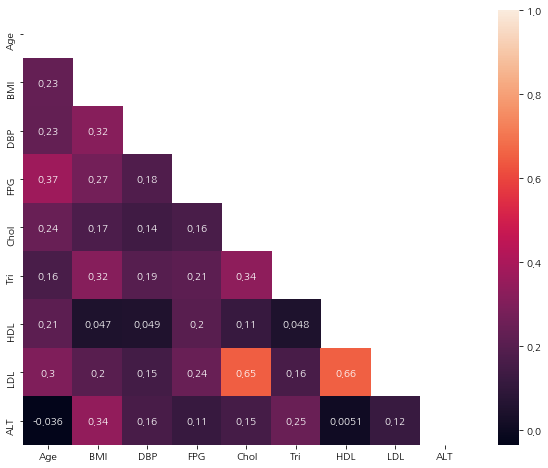

In [30]:
# 상관관계 분석: 선형(피어슨)
plt.figure(figsize=(10, 8))
corr = dt1.select_dtypes('number').corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

다음의 feature간 다소 높은 양의 상관관계를 보임(비선형 상관관계가 있을 수도 있지만, 이번 문제에서는 선형 관계만 고려하도록 한다.)
- 칼로리(Chol)와 혈중 저밀도지단백 콜레스테롤 수치(LDL): 0.65
- 혈중 저밀도지단백 콜레스테롤 수치(LDL)와 혈중 고밀도지단백 콜레스테롤 수치(HDL): 0.66 

따라서, 해당 컬럼 간 다소 높은 다중공선성을 보인다고 볼 수도 있으나, 차원 수가 높지 않으며(10) 대다수의 컬럼에서는 유의미한  
상관관계(선형) 보이지 않으므로 PCA 등의 차원축소는 반드시 필요하다고 볼 수 없다. 

다만, 향후 모델 성능 저하나 다중공선성으로 인한 회귀계수 불안정이 의심될 경우, VIF 분석 등을 통한 추가 검토가 바람직함

#### 2.  데이터 전처리가 필요하다면 수행하고 이유를 작성하시오.

chol 칼럼에 결측치가 1개(0.02%) 존재함. 결측률이 높지 않아 분석에 큰 영향을 주지 않을 것이므로 삭제한다.

#### 3.  train test set을 DBP 컬럼 기준으로 7:3 비율로 나눈 후 잘 나뉘었는지 통계적으로 나타내시오.

단순 무작위 샘플링을 통해 훈련 데이터와 테스트 데이터를 7:3으로 분할한다.

In [31]:
from sklearn.model_selection import train_test_split
Y = dt1['DBP']
X = dt1.drop('DBP', axis=1)

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.3, random_state=42)

print(train_X.shape, test_X.shape)

(3011, 9) (1291, 9)


훈련 데이터와 테스트 데이터의 각 칼럼별 분포의 유사성을 통계적으로 비교하고자 한다.  
두 분포의 유사성을 통계적으로 검정하는 방법은 K-S 테스트를 활용해볼 수 있다.  
K-S(Kolmogorov–Smirnov 2-sample) 테스트는 두 집단의 분포(형태, 위치, 스케일)를 검정할 수 있는 대표적인 비모수 기법이다.
- 가설수립
  - H0: 두 데이터셋은 동일한 분포를 따른다. 
  - H1: 두 데이터셋은 동일한 분포를 따르지 않는다.

In [32]:
from scipy.stats import ks_2samp

for col in train_X.columns:
    stat, p = ks_2samp(train_X[col], test_X[col])
    print(f"{col} 통계량: {stat:.3f}, p-value: {p:.3f}, 귀무가설", "기각" if p < 0.05 else "기각 x")

Age 통계량: 0.023, p-value: 0.697, 귀무가설 기각 x
Gender 통계량: 0.023, p-value: 0.700, 귀무가설 기각 x
BMI 통계량: 0.026, p-value: 0.579, 귀무가설 기각 x
FPG 통계량: 0.035, p-value: 0.204, 귀무가설 기각 x
Chol 통계량: 0.018, p-value: 0.933, 귀무가설 기각 x
Tri 통계량: 0.020, p-value: 0.836, 귀무가설 기각 x
HDL 통계량: 0.026, p-value: 0.570, 귀무가설 기각 x
LDL 통계량: 0.037, p-value: 0.174, 귀무가설 기각 x
ALT 통계량: 0.015, p-value: 0.981, 귀무가설 기각 x


유의수준 5% 하에서 모든 feature의 p-value가 0.05 보다 크므로 귀무가설을 기각할 수 없다.  
**따라서, train, test set은 동일한 분포로 잘 나누어졌다.**

#### 4. 독립변수의 차원축소의 필요성을 논하고, 필요에 따라 차원을 축소하고 불필요하다면 그 근거를 논하시오.

차원축소는 변수 간의 중복 정보 제거, 고차원일 시 연산속도 향상, 과적합 방지를 위해 활용할 수 있다.

해당 데이터셋은 학습에 사용하는 feature가 9개로 고차원이 아니며, 데이터 수 또한 많지 않고, (`hdl`, `ldl`), (`chol`, `ldl`)  
feature간의 다소 높은 상관관계를 제외하고는 feature간 상관관계가 높지 않으므로 차원축소를 반드시 사용할 필요가 없다.  
따라서 이번 문제에서는 차원축소를 사용하지 않는다.   
(다만, 향후 모델 성능 저하나 다중공선성으로 인한 회귀계수 불안정이 의심될 경우, VIF 분석 등을 통한 추가 검토가 바람직함)

#### 5.  데이터가 회귀분석의 기본가정 따르는지 설명하시오.

훈련 데이터를 활용하여 회귀분석을 실시한다.  
선형회귀 모델은 스케일에 영향은 받지않고 작동은 하나, 회귀계수의 해석, 모델 해석력, 정규화 회귀(Lasso, Ridge 등),   
**다중공선성 측정(VIF)**에서는 스케일 조정이 필요하므로 수행 후 회귀분석 수행

<회귀분석의 기본가정>

| 번호 | 가정                                  | 설명                                            |
| -- | ----------------------------------- | --------------------------------------------- |
| 1  | **선형성 (Linearity)**                 | 독립변수와 종속변수 간에는 선형적인 관계가 있어야 함                 |
| 2  | **독립성 (Independence)**              | 오차(Residual)들은 서로 독립이어야 함 (특히 시간 순서 데이터에서 중요) |
| 3  | **등분산성 (Homoscedasticity)**         | 모든 수준의 독립변수에서 오차의 분산이 일정해야 함                  |
| 4  | **정규성 (Normality)**                 | 오차항은 정규분포를 따라야 함 (주로 신뢰구간, 가설검정에 필요)          |
| 5  | **다중공선성 없음 (No multicollinearity)** | 독립변수들 간에 강한 상관관계가 없어야 함                       |

<가정별 진단방법>

| 가정       | 진단 방법                                  |
| -------- | -------------------------------------- |
| 선형성      | 잔차 vs. 예측값 산점도 확인 (선형 패턴 여부)           |
| 독립성      | Durbin-Watson 통계량 (시계열), ACF/PACF      |
| 등분산성     | 잔차 플롯(Residual Plot), Breusch-Pagan 검정 |
| 정규성      | Q-Q plot, Shapiro-Wilk test            |
| 다중공선성 없음 | VIF(분산팽창지수), 조건수(Condition number)     |

**독립성은 시계열 데이터에서는 반드시 확인해야 하지만, 이번 문제는 시계열 데이터가 아니기 때문에 생략한다.**



In [33]:
#스케일링 수행
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

s_col = ['Age', 'BMI', 'FPG', 'Chol', 'Tri', 'HDL', 'LDL', 'ALT']

train_X[s_col] = sc.fit_transform(train_X[s_col])
test_X[s_col] = sc.transform(test_X[s_col])

In [34]:
train_X.head()

,Age,Gender,BMI,FPG,Chol,Tri,HDL,LDL,ALT
848,-1.107279,1,-0.857132,0.191210,-0.387595,-0.223430,-0.459210,-0.388280,0.222616
2917,-1.107279,1,0.471788,-0.203163,0.473824,-0.453670,-0.568581,0.012639,-0.080852
3080,1.690059,1,-0.679943,-0.177720,0.613805,1.395930,-0.541238,-0.321460,-0.405996
3270,0.803098,1,0.146941,1.539714,-1.259783,-0.430646,-0.513895,-1.023068,-0.488366
3249,0.189048,1,1.682582,1.921365,0.064650,0.651485,-0.696179,-0.187820,1.089666


In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

train = pd.concat([train_X, train_Y], axis=1)

lm_model = smf.ols("DBP ~ C(Gender)+Age+BMI+FPG+Chol+Tri+HDL+LDL+ALT", data=train).fit()
lm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    DBP   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     58.23
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           1.89e-98
Time:                        10:03:34   Log-Likelihood:                -11274.
No. Observations:                3011   AIC:                         2.257e+04
Df Residuals:                    3001   BIC:                         2.263e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         77.2694      0.240    322.133      0.000      76.799      77.740
C(Gender)[T.2]    -2.6436      0.420     -6.298      0.000      -3.467      -1.821
Age                1.6434      0.212      7.756      0.000       1.228       2.059
BMI                2.3000      0.218     10.551      0.000       1.873       2.727
FPG                0.3148      0.210      1.502      0.133      -0.096       0.726
Chol               0.1105      0.320      0.346      0.730      -0.516       0.737
Tri                0.6686      0.216      3.092      0.002       0.245       1.092
HDL               -0.3386      0.315     -1.075      0.282      -0.956       0.279
LDL                0.5942      0.410      1.450      0.147      -0.209       1.398
ALT                0.3291      0.204      1.611      0.107      -0.071       0.730
==============================================================================
Omnibus:                      128.314   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              177.909
Skew:                           0.416   Prob(JB):                     2.33e-39
Kurtosis:                       3.853   Cond. No.                         4.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### 1. 선형성 검정: 잔차 vs. 예측값(($e_i = y_i - \hat{y}_i \quad \text{vs} \quad \hat{y}_i$) 산점도 확인(선형 패턴 여부)
##### 2. 등분산성 검정: 잔차(Residual) Plot

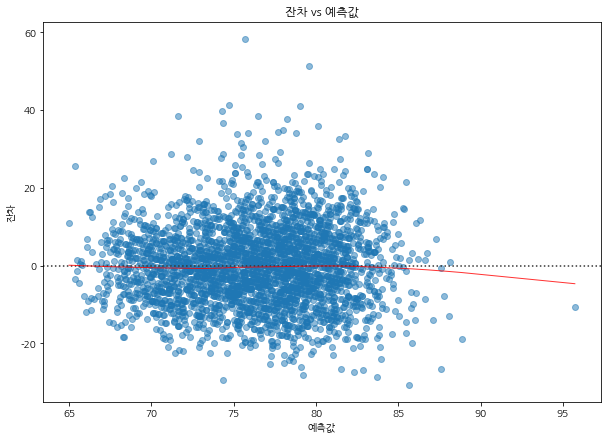

In [36]:
pred_y = lm_model.fittedvalues

plt.figure(figsize=(10, 7))
# scatter plot
sns.residplot(x=pred_y, y='DBP', data=train, lowess=True, 
             scatter_kws={'alpha':0.5}, 
             line_kws={'color':'r', 'lw':1, 'alpha':0.8})

plt.title('잔차 vs 예측값')
plt.xlabel("예측값")
plt.ylabel("잔차")
plt.show()

- 잔차가 0을 중심으로 무작위로 고르게 분포하고 있으며, LOWESS 곡선 또한 직선에 가까운 형태를 보이므로 선형성 가정을 만족한다고 판단된다.

- 또한 예측값의 크기에 따라 잔차의 분산이 증가하거나 감소하는 경향이 관찰되지 않으므로, 등분산성 가정(homoscedasticity) 역시 충족된 것으로 보인다.

**추가. 선형성/등분산성 검정: 표준화 잔차와 예측치의 산점도**

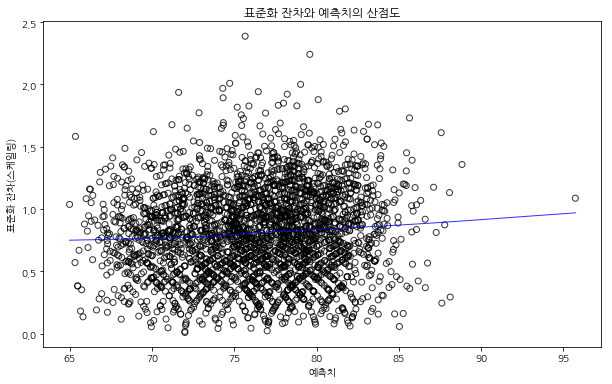

In [48]:
plt.figure(figsize=(10, 6))
sns.regplot(x = lm_model.fittedvalues, 
            y = np.sqrt(np.abs(lm_model.get_influence().resid_studentized_internal)),
            scatter=True, 
            ci= False, 
            lowess=True, 
            line_kws={'color':'b', 'lw':1, 'alpha':0.8}, 
            scatter_kws={'facecolors':'none', 'edgecolors':'black'})

plt.title('표준화 잔차와 예측치의 산점도')
plt.xlabel('예측치')
plt.ylabel("표준화 잔차(스케일링)")
plt.show()

점들이 체계적으로 증가하거나 감소하는 패턴이 없으므로, 등분산 가정을 만족

##### 3. 정규성 확인: QQ plot(표준화 잔차의 표본분위수와 정규분포의 이론 분위수와의 산점도)

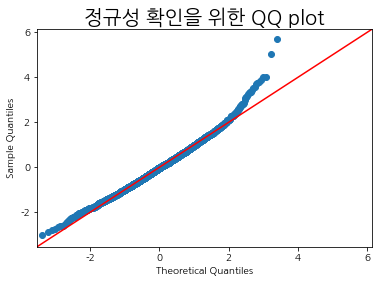

In [38]:
qq = sm.ProbPlot(lm_model.get_influence().resid_studentized_internal, fit=True)  # 회귀 모델의 내부 표준화 잔차
fig = qq.qqplot(line='45', color='black')
plt.title('정규성 확인을 위한 QQ plot', fontsize=20)
plt.show()

**추가: shapiro wilk test**

In [39]:
from scipy.stats import shapiro

s_stat, p = shapiro(lm_model.resid) #잔차를 넣음

print(f"유의수준 5% 하에서 p-value {p:.3f}이므로 정규성을", "만족한다." if p > 0.05 else "만족하지 않는다.")

유의수준 5% 하에서 p-value 0.000이므로 정규성을 만족하지 않는다.


- QQ-plot의 경우 양끝 꼬리 부분을 제외하고는 대부분의 점이 45도 선에 붙어서 직선 형태에 가까우므로 정규성 가정을 만족한다고 볼수 있음  
  (표준화잔차의 표본 분위수와 정규분포의 이론 분위수는 유사)
- shapiro wilk test 결과, 유의수준 5% 하 p-value가 0.05 이하로 정규성을 만족하지 않는다는 결과가 나왔지만, 데이터 수가 4300여개로  
  많다고 볼 수 없고, QQ-plot 결과와 비교해보았을 시,   
  
**정규성을 만족한다고 판단한다.**

##### 4. 다중공선성: 다중공선성 없음(VIF:분산팽창지수)
- VIF: 특정 독립변수가 다른 독립변수들과 얼마나 강한 상관관계를 가지는지 수치화한 것   - VIF가 높을수록 다중공선성(중복정보) 가 높음

- 공식
$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

| VIF 값       | 해석                     |
| ----------- | ---------------------- |
| **1**       | 다중공선성 없음 (이상적)         |
| **1 \~ 5**  | 약한 다중공선성 (대체로 무시 가능)   |
| **5 \~ 10** | 다소 강한 다중공선성 (주의 필요)    |
| **10 이상**   | 심각한 다중공선성 → 제거/차원축소 고려 |



In [57]:
# vif 검증
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = add_constant(train_X) #절편추가

#vif 계산
vif_df = pd.DataFrame()
vif_df['feature'] = x.columns
vif_df['VIF'] = [variance_inflation_factor(x.values,  i) for i in range(x.shape[1])]

display(vif_df[1:]) #절편은 해석에서 제외

,feature,VIF
1,Age,1.287336
2,Gender,1.162214
3,BMI,1.362700
4,FPG,1.259708
5,Chol,2.929612
6,Tri,1.340604
7,HDL,2.843776
8,LDL,4.815185
9,ALT,1.196802


feature 중 Chol, HDL, LDL에서 약한 다중공선성을 보이나,  
나머지 feature들은 대체로 1에 가까운 "다중공선성 없음"을 보이고 있으므로  

**다중공선성 없음(다른 독립변수들과 상관관계 없음)을 만족**한다고 볼 수 있다.


**<GPT 답변>**  
전체적으로 대부분 변수는 VIF가 1~2 수준으로, 다중공선성 문제는 거의 없음

다만:

LDL (4.82), Chol (2.93), **HDL (2.84)**는 서로 상관관계가 높은 생화학 지표들이므로 약간의 다중공선성이 있는 것으로 보임

LDL은 거의 5에 가까우므로 모델 안정성이나 해석 목적이라면 조치(제외, 차원축소 등) 고려 가능

#### 5. 독립성 검정: 시계열 데이터가 아니므로 필수 사항은 아님
- Durbin-Watson 검정(보통은 시계열에서 검정), ACF/PACF로도 가능
- 관측값 간 순서에 의미가 있거나 오차의 독립성이 의심되는 상황

| DW 값 범위    | 해석                |
| ---------- | ----------------- |
| ≈ 2        | 자기상관 없음 (독립성 만족)  |
| < 2        | 양(+)의 자기상관 존재 가능성 |
| > 2        | 음(−)의 자기상관 존재 가능성 |
| ≈ 0 또는 ≈ 4 | 강한 자기상관 → 문제 있음   |


In [62]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(lm_model.resid)

print(f"Durbin-Watson 통계량: {dw_stat:.3f}")

Durbin-Watson 통계량: 2.018


통계량이 2에 매우 근접하므로 오차항 간의 자기상관(autocorrelation)이 거의 없다고   
판단할 수 있으며, 독립성 가정은 만족된 것으로 봐도 무방함

### 6. 회귀분석 알고리즘 3개를 선택하고 선정이유와 장단점을 비교하시오.

| 구분    | 상황 (SITUATION) | 알고리즘                                     | 설명              | 특징                       |
| ----- | -------------- | ---------------------------------------- | --------------- | ------------------------ |
| **1** | 기본 선형관계 가정     | **선형 회귀** (Linear Regression)            | 가장 기본적인 회귀모델    | 빠르고 해석 용이, 선형성 가정 필요     |
|       |                | **릿지 회귀** (Ridge Regression)             | L2 정규화          | 다중공선성 완화, 모든 변수 유지       |
|       |                | **라쏘 회귀** (Lasso Regression)             | L1 정규화          | 변수 선택 기능, 일부 계수 0으로 만듦   |
| **2** | 비선형 추정 필요      | **다항 회귀** (Polynomial Regression)        | 입력 변수의 다항식 변환   | 복잡한 곡선 형태 추정, 과적합 주의     |
|       |                | **KNN 회귀** (KNN Regressor)               | 가장 가까운 k개 평균 사용 | 비선형, 이상치 민감, 느릴 수 있음     |
|       |                | **SVR** (Support Vector Regression)      | 서포트 벡터 기반 회귀    | 고차원 대응 가능, 느릴 수 있음       |
| **3** | 고성능 예측 목표      | **랜덤 포레스트 회귀** (Random Forest Regressor) | 앙상블 트리 기반       | 변수 중요도 제공, 과적합 적음        |
|       |                | **XGBoost / LightGBM**                   | 부스팅 기반 앙상블      | 매우 강력한 성능, 하이퍼파라미터 튜닝 필요 |
|       |                | **신경망 회귀** (MLPRegressor)                | 다층 퍼셉트론         | 복잡한 비선형도 가능, 해석 어려움      |
| **4** | 시계열 데이터        | **ARIMA / SARIMA**                       | 전통적인 시계열 모델     | 추세/계절성 분석에 적합            |
|       |                | **Prophet** (by Meta)                    | 시계열 자동 모델링      | 휴일/계절성 자동 처리, 쉬운 사용      |
|       |                | **LSTM** (딥러닝 시계열)                       | 순환 신경망 기반       | 장기 패턴 학습, 복잡도 높음         |


이번 문제에서는 선형회귀 모델의 가정사항 5가지(선형성, 정규성, 등분산성, 독립성, 다중공선성)를 모두 만족한다고 볼 수 있기 때문에,  
가장 기본적이며 빠르고 해석이 용이한 선형 회귀분석(Linear Regression), 일부 독립변수에서 다소 강한 다중공선성에 가까움을 보이므로,  
이를 완화하기 위한 L2 정규화를 활용한 릿지 회귀(Ridge Regression), 마지막으로 앙상블 트리기반으로 비교적 성능이 좋은  
랜덤 포레스트 회귀모델(Random Forest Regressor)를 사용하도록 한다.

1. Linear Regression
2. Ridge Regression
3. Random Forest Regressor

| 모델                                    | 장점                                                                                | 단점                                                          | 추천 상황                                                |
| ------------------------------------- | --------------------------------------------------------------------------------- | ----------------------------------------------------------- | ---------------------------------------------------- |
| **1. Linear Regression**<br>*(선형 회귀)* | ✅ 간단하고 빠름<br>✅ 계수 해석 용이 (변수 영향력 파악)<br>✅ 구현 쉬움, 해석 중심 모델                          | ❌ 선형 관계 가정<br>❌ 이상치와 다중공선성에 민감<br>❌ 예측 성능 낮을 수 있음           | - 데이터가 작고<br>- 선형 가정이 성립되며<br>- **해석이 중요한 경우**       |
| **2. Ridge Regression**<br>*(릿지 회귀)*  | ✅ L2 정규화로 **다중공선성 완화**<br>✅ 예측 안정성 향상<br>✅ 모든 변수를 유지하면서 과적합 억제                    | ❌ 계수 해석 어려움<br>❌ 변수 선택 불가능 (불필요한 변수도 남음)<br>❌ λ(규제강도) 튜닝 필요 | - 다중공선성이 의심될 때<br>- 해석보다 **예측 안정성**이 중요한 경우          |
| **3. Random Forest Regressor**        | ✅ 비선형, 상호작용 관계 자동 학습<br>✅ 이상치·다중공선성·스케일 영향 적음<br>✅ 변수 중요도 제공<br>✅ 과적합에 강한 편 (앙상블) | ❌ 느릴 수 있음<br>❌ 해석 불가능<br>❌ 고차원일 경우 메모리/시간 ↑                 | - **정확도 우선**<br>- 복잡한 데이터 구조<br>- 변수 간 관계가 명확하지 않을 때 |



| 모델                    | 적합한 상황                                                |
| --------------------- | ----------------------------------------------------- |
| **Linear Regression** | 데이터가 적고, 관계가 단순하며 **해석이 중요한 경우**                      |
| **Random Forest**     | 변수 수가 많고, **복잡한 비선형** 문제에 **빠른 적용**이 필요한 경우           |
| **Ridge Regression**           | **변수간 다중공선성이 강해**,**완화가 필요한 경우** |


- 3개의 회귀 분석 모델링을 진행하고, 평가지표 rmse로 가장 최적화된 알고리즘 선정하시오.
- 교차 검증 이용

독립변수 데이터는 이전에 스케일링한 데이터를 그대로 사용하고, KFold(5) 교차검증 방법을 적용한다.  
평가지표로는 MSE를 1/2제곱한 평균제곱근 오차를 사용한다. 

지도학습 방식으로 train set을 활용해 데이터 학습 후, test set을 통해 성능을 비교한다.

In [65]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#변수형 범주 전처리: Gender
train_X = pd.get_dummies(train_X, columns=['Gender'], drop_first=True) #남성이면 0, 여성이면 1
test_X = pd.get_dummies(test_X, columns=['Gender'], drop_first=True)
test_X = test_X.reindex(columns=train_X.columns, fill_value=0)

##### 6-1.Linear Regression

In [86]:
# rmse 가 없어서 함수를 만들어 준다.
from sklearn.metrics import make_scorer

def rmse_func(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

rmse = make_scorer(rmse_func, greater_is_better=False)


#5-Fold
kf = KFold(n_splits=5, random_state=42, shuffle=True)

#모델 정의
lr_model = LinearRegression()
param1 = {'fit_intercept': [False]}

lr_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param1, 
    scoring=rmse, 
    cv = kf)

lr_search.fit(train_X, train_Y)

print(f"[선형회귀 모델] train set의 Best Score: {-lr_search.best_score_}")

train_pred = lr_search.predict(train_X)
test_pred = lr_search.predict(test_X)

train_rmse = np.sqrt(mean_squared_error(train_Y, train_pred))
test_rmse = np.sqrt(mean_squared_error(test_Y, test_pred))

print(f"[선형회귀 모델] train set rmse: {train_rmse:.3f}")
print(f"[선형회귀 모델] test set rmse: {test_rmse:.3f}")

[선형회귀 모델] train set의 Best Score: 61.19294776325488
[선형회귀 모델] train set rmse: 61.017
[선형회귀 모델] test set rmse: 62.394


##### 6-2.Redge Regression

In [87]:
rg_model = Ridge(random_state=42)

#작은 alpha → 규제 약함 → 선형회귀와 비슷해짐 → 과적합 가능성 ↑
#큰 alpha → 규제 강함 → 모델 단순화 → 과소적합 가능성 ↑
param2 = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]} # 보통 log scale로 증가

rg_search = GridSearchCV(
    estimator=rg_model,
    param_grid=param2, 
    scoring=rmse, 
    cv = kf)

rg_search.fit(train_X, train_Y)

print(f"[릿지회귀 모델] train set의 Best Score: {-rg_search.best_score_}")

train_pred = rg_search.predict(train_X)
test_pred = rg_search.predict(test_X)

train_rmse = np.sqrt(mean_squared_error(train_Y, train_pred))
test_rmse = np.sqrt(mean_squared_error(test_Y, test_pred))

print(f"[릿지회귀 모델] train set rmse: {train_rmse:.3f}")
print(f"[릿지회귀 모델] test set rmse: {test_rmse:.3f}")

[릿지회귀 모델] train set의 Best Score: 10.2632443583542
[릿지회귀 모델] train set rmse: 10.231
[릿지회귀 모델] test set rmse: 9.896


##### 6-3. Random Forest Regressor

In [88]:
rf_model = RandomForestRegressor(random_state=42)

param3 = {'max_features': np.arange(0.5, 1, 0.1)} 

rf_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param3, 
    scoring=rmse, 
    cv = kf)

rf_search.fit(train_X, train_Y)

print(f"[랜덤 포레스트 회귀 모델] train set의 Best Score: {-rf_search.best_score_}")

train_pred = rf_search.predict(train_X)
test_pred = rf_search.predict(test_X)

train_rmse = np.sqrt(mean_squared_error(train_Y, train_pred))
test_rmse = np.sqrt(mean_squared_error(test_Y, test_pred))

print(f"[랜덤 포레스트 회귀 모델] train set rmse: {train_rmse:.3f}")
print(f"[랜덤 포레스트 회귀 모델] test set rmse: {test_rmse:.3f}")

[랜덤 포레스트 회귀 모델] train set의 Best Score: 10.404067610445193
[랜덤 포레스트 회귀 모델] train set rmse: 3.895
[랜덤 포레스트 회귀 모델] test set rmse: 10.079


## 문제 2

**Data description**

교통사고와 관련된 다양한 정보들을 포함하는 사고 기록 데이터입니다.

-   **사고내용**: 사고가 발생한 상황에 대한 설명

-   **가해자성별**: 사고를 일으킨 가해자의 성별

-   **가해자연령**: 사고를 일으킨 가해자의 연령

-   **가해자차종**: 가해자가 운전한 차량의 종류

-   **피해자신체상해정도**: 사고로 인해 피해자가 입은 신체 상해의 정도

-   **사고유형**: 사고의 유형 (예: 추돌, 전복, 충돌 등)

-   **기상상태**: 사고 발생 당시의 기상 상태 (예: 맑음, 비, 눈 등)

-   **사망자수**: 사고로 인한 사망자 수

-   **발생시각**: 사고가 발생한 시간


In [ ]:
dat = pd.read_csv('problem2.csv')
dat.head(2)

In [ ]:
dat.info()

In [ ]:
dat.isna().sum()

가해자성별 10개, 가해자성별 4개의 결측치가 존재하는 것을 확인할 수 있다. 해당 정보는 가해자 신상정보이므로, 결측치를 대치하는 것은 적절하지 않다. 전체 데이터 대비 결측치의 비율이 크지 않으므로 결측치를 삭제한다.

In [ ]:
dat = dat.dropna()

가해자연령 칼럼을 수치형으로 변환한다.

In [ ]:
#re.sub(r'[^0-9]', '', '18세')
import re

def delete_text(x):
    x = re.sub(r'[^0-9]', '', str(x))
    return x

dat['가해자연령'].apply(lambda x: delete_text(x)).head(3)

In [ ]:
dat['가해자연령'] = dat['가해자연령'].apply(lambda x: delete_text(x))
dat = dat.astype({'가해자연령' : 'int64'})

1.  **평일/주말을 구분하는 ‘주말여부’ 변수를 추가하고 데이터 분포를 확인하시오.**

요일 칼럼을 활용하여 `주말여부` 칼럼을 생성한다.

In [ ]:
def delete_text2(x):
    x = re.sub('시', '', str(x))
    return x

dat['발생시각'].apply(lambda x: delete_text2(x)).head(3)

In [ ]:
from datetime import datetime
dat['발생시각'] = dat['발생시각'].apply(lambda x: delete_text2(x))
dat['발생시각'] = pd.to_datetime(dat['발생시각'], format='%Y-%m-%d %H')
dat['요일'] = dat['발생시각'].dt.day_name()
dat = dat.assign(주말여부 = np.where(dat['요일'].isin(['Saturday', 'Sunday']), 'Yes', 'No'))
dat = dat.drop(['요일', '발생시각'], axis = 1)

In [ ]:
from matplotlib import font_manager, rc
rc('font', family='AppleGothic')            ## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False 

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.countplot(dat['주말여부'])
plt.show();

주말이 아닌 날이 주말인 날보다 높은 것을 확인할 수 있다.

1.  **주말여부에 따라 각 변수들(사고내용, 가해자성별, 가해자연령, 기상상태, 사고유형)이 통계적으로 유의한지 검정하시오.**

In [ ]:
from scipy.stats import chi2_contingency
table1 = pd.crosstab(dat['주말여부'], dat['사고내용'])

chi2, p, df, expected = chi2_contingency(table1)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

-   **귀무가설 (H0)**: 주말여부와 사고내용은 서로 독립적이다. 즉, 주말 여부가 사고내용에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 사고내용은 서로 독립적이지 않다. 즉, 주말 여부가 사고내용에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.05로 귀무가설을 기각할 수 없다. 따라서 주말 여부와 사고 내용(중상, 경상) 간에는 통계적으로 유의미한 관계가 존재하지 않는다.

In [ ]:
table2 = pd.crosstab(dat['주말여부'], dat['가해자성별'])
chi2, p, df, expected = chi2_contingency(table2)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

N = np.sum(table2.values) 
minimum_dimension = min(table2.shape)-1
Cramer_v = np.sqrt((chi2/N) / minimum_dimension) 
print('Cramer v :', np.round(Cramer_v, 2))

-   **귀무가설 (H0)**: 주말여부와 가해자성별은 서로 독립적이다. 즉, 주말 여부가 가해자성별에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 가해자성별은 서로 독립적이지 않다. 즉, 주말 여부가 가해자성별에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.001로 귀무가설을 기각한다. 따라서 주말 여부와 가해자성별 간에는 통계적으로 유의미한 관계가 존재한다. cramer's v = 0.07로 연관성의 강도는 크지 않다.

In [ ]:
table3 = pd.crosstab(dat['주말여부'], dat['사고유형'])
chi2, p, df, expected = chi2_contingency(table3)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

-   **귀무가설 (H0)**: 주말여부와 사고유형은 서로 독립적이다. 즉, 주말 여부가 사고유형에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 사고유형은 서로 독립적이지 않다. 즉, 주말 여부가 사고유형에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.7로 귀무가설을 기각할 수 없다. 따라서 주말 여부와 사고유형(차대차 - 기타, 차대차 - 측면충돌, 차대차 - 추돌, 차대사람 - 기타 ) 간에는 통계적으로 유의미한 관계가 존재하지 않는다.

In [ ]:
table4 = pd.crosstab(dat['주말여부'], dat['기상상태'])
chi2, p, df, expected = chi2_contingency(table4)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

-   **귀무가설 (H0)**: 주말여부와 기상상태은 서로 독립적이다. 즉, 주말 여부가 기상상태에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 기상상태은 서로 독립적이지 않다. 즉, 주말 여부가 기상상태에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.06로 귀무가설을 기각한다. 따라서 주말 여부와 기상상태(맑음, 비, 흐림 ) 간에는 통계적으로 유의미한 관계가 존재한다. cramer's v = 0.04로 연관성의 강도는 크지 않다.

In [ ]:
from scipy.stats import ttest_ind

aa1 = dat.loc[dat['주말여부'] == 'Yes', '가해자연령']
aa2 = dat.loc[dat['주말여부'] == 'No', '가해자연령']
ttest_ind(aa1, aa2, equal_var = False)

-   **귀무가설 (H0)**: 주말여부에 따른 가해자연령의 평균 차이가 없다.

-   **대립가설 (H1)**: 주말여부에 따른 가해자연령의 평균 차이가 있다.

welch t-test 결과 유의 수준 5%에서 p-value = 0.12로 귀무가설을 기각할 수 없다. 따라서 주말 여부와 가해자연령 간에는 통계적으로 유의미한 관계가 존재하지 않는다.

1.  **SMOTE 오버샘플링하고 변수별 빈도를 나타내고 연속형변수의 경우 평균을 구하시오.**

SMOTE 샘플링을 하기 전에 훈련 데이터와 테스트 데이터를 분할한다. 주말여부 칼럼의 분포를 확인해보면 클래스 불균형이 존재하므로, 층화 샘플링을 통해 훈련데이터와 테스트 데이터를 분할한다.


In [ ]:
y = dat['사고내용']
X = dat.drop(['사고내용'], axis = 1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, stratify = X['주말여부'], random_state = 0)

훈련 데이터에 SMOTE 샘플링을 적용한다.

-   SMOTE를 적용하기 위해서는 전부 numeric 이어야 하므로 변환 실시

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer

cat_columns = train_X.select_dtypes('object').columns.to_list()
num_columns = train_X.select_dtypes('number').columns.to_list()

transformer = make_column_transformer(
    (OrdinalEncoder(), cat_columns),
    remainder='passthrough')

encode_data = transformer.fit_transform(train_X)
label_train_X = pd.DataFrame(encode_data, columns = train_X.columns)

-   SMOTE 적용

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 0)
train_X_smote, train_y_smote = smote.fit_resample(label_train_X, train_y)
print(Counter(train_y_smote))

-   categorical variable 역변환

In [ ]:
aa = transformer.named_transformers_['ordinalencoder']
invese_cat_data = aa.inverse_transform(train_X_smote.iloc[:, :6])  # 핵심 수정
invese_cat_data = pd.DataFrame(invese_cat_data, columns=cat_columns)


-   역변환한 데이터 결합

In [ ]:
train_X_smote_sub = pd.DataFrame(train_X_smote, columns = train_X.columns)

train_X_smote_sub = train_X_smote_sub.drop(cat_columns, axis = 1)

train_X_smote = pd.concat([invese_cat_data, train_X_smote_sub], axis = 1)
train_X_smote.head(2)

연속형 변수의 빈도를 나타내면 다음과 같다.

In [ ]:
train_X_smote.loc[:, num_columns].mean()

범주형 변수의 빈도를 나타내면 다음과 같다.

In [ ]:
for i in range(len(cat_columns)):
    print(train_X_smote[cat_columns[i]].value_counts())

1.  **로지스틱회귀분석, XGBoost 모형을 활용하여 분류분석을 수행하시오.**

In [ ]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_y = le.fit_transform(train_y)
test_y = le.fit_transform(test_y)

In [ ]:
cat_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

preprocess = ColumnTransformer([('cat', cat_preprocess, cat_columns)], remainder='passthrough')

pipe_lg = Pipeline(
    [
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state = 0)),
        ("classifier", LogisticRegression(solver='liblinear')) 
    ]
)
pipe_lg.fit(train_X, train_y)

cv = KFold(n_splits = 5, shuffle = True, random_state = 0)
cv_score = cross_val_score(pipe_lg, train_X, train_y, scoring='balanced_accuracy', cv = cv)
print('Logistic regression best score : ', np.mean(cv_score))

In [ ]:
import xgboost as xgb
xgb_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state = 0)),
        ("classifier", xgb.XGBClassifier()) 
    ]
)

Xgb_param = {'classifier__learning_rate': np.arange(0.01, 0.3, 0.05)}

Xgb_search = GridSearchCV(estimator = xgb_pipe, 
                      param_grid = Xgb_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
Xgb_search.fit(train_X, train_y)

print('xgboost best score : ', Xgb_search.best_score_)

모델별로 성능을 비교해보면 Balanced accuracy는 대략 0.98이며, logistic regression의 성능이 가장 좋다. 따라서 최종 모형으로 logistic regression 모형을 선택한다.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
pred_lg = pipe_lg.predict(test_X)
print(classification_report(test_y, pred_lg))
balanced_accuracy_score(test_y, pred_lg)

# 통계

## 문제 3

별도의 데이터 없음

**아래 데이터는 3개의 철강 제조 공장(공장 A, 공장 B, 공장 C)에서 생산된 제품을 3개의 지역(지역 1, 지역 2, 지역 3)으로 배송할 때 발생하는 운송비용과 공장별 총 생산량, 지역별 총 수요량입니다. 이 데이터를 활용하여 총 운송비를 최소로 하는 운송 계획을 수립하시오. (단, 각 공장에서는 3개 지역으로만 운송되고, 공장 간 또는 지역 간 운송은 없다고 가정한다.)**

표 : 운송비용과 공장별 총 생산량, 지역별 총 수요량

| 구분      | 지역 1 | 지역 2 | 지역 3 | 총 생산량 |
|-----------|--------|--------|--------|-----------|
| 공장 A    | 12만원 | 5만원  | 34만원 | 70개      |
| 공장 B    | 22만원 | 2만원  | 21만원 | 55개      |
| 공장 C    | 3만원  | 23만원 | 15만원 | 25개      |
| 총 수요량 | 30개   | 50개   | 70개   | NA        |


총 운송비를 최소화 하는 문제이기 때문에 선형계획법을 사용하여, 목적함수를 최소화 하는 값을 찾는 것이 목적이다.  

Scipy.optimize의 iinprog 함수를 사용한다. 

| 파라미터           | 설명                                    |
| -------------- | ------------------------------------- |
| `c`            | 목적 함수 계수 벡터 (최소화 대상: $c^T x$)         |
| `A_ub`, `b_ub` | 부등식 제약조건 $A_{ub} x \le b_{ub}$        |
| `A_eq`, `b_eq` | 등식 제약조건 $A_{eq} x = b_{eq}$           |
| `bounds`       | 각 변수의 범위: 예시 `[(0, None), (0, None)]` |
| `method`       | 알고리즘 선택 (`'highs'`가 기본이고 가장 권장됨)      |

- 목적함수  
  - Min_cost = (12x1 + 5x2 + 34x3) + (22x4 + 2x5 + 21x6) + (3x7 + 23x8 + 15x9)
  
- 제약조건
  1. x1 + x2 + x3 = 70
  2. x4 + x5 + x6 = 55
  3. x7 + x8 + x9 = 25
  4. x1 + x4 + x7 = 30
  5. x2 + x5 + x8 = 50
  6. x3 + x6 + x9 = 70
  7. x1, x2, x3, x4, x5, x6, x7, x8, x9 >= 0

In [ ]:
import numpy as np
from itertools import product
from scipy.optimize import linprog

#비용행렬
costs = [12, 5, 34, 22, 2, 21, 3, 23, 15]
supply = [70, 55, 25] #공급량
demand = [30, 50, 70] #수요량

#제약조건 행렬 9*6
A_eq = [
    [1, 1, 1, 0, 0, 0, 0, 0, 0], 
    [0, 0, 0, 1, 1, 1, 0, 0, 0], 
    [0, 0, 0, 0, 0, 0, 1, 1, 1], 
    [1, 0, 0, 1, 0, 0, 1, 0, 0], 
    [0, 1, 0, 0, 1, 0, 0, 1, 0], 
    [0, 0, 1, 0, 0, 1, 0, 0, 1]
]
#제약조건 상수
B_eq = np.concatenate([supply, demand])

#선형계획
result = linprog(c=costs, A_eq= A_eq, b_eq = B_eq, bounds=[(0, None)]*9, method='highs')

In [ ]:
import pandas as pd

print(f"최적의 운송비: {round(result.fun)} 원")
label = ['A_1', 'A_2', 'A_3', 'B_1', 'B_2', 'B_3', 'C_1', 'C_2', 'C_3'] #공장_지역
mx = pd.DataFrame(result.x.reshape(3, 3), columns=['지역1', '지역2', '지역3'], index= ['A공장', 'B공장', 'C공장'])
display(mx)

## 문제 4

**Data description**

개인의 헤드셋 보유 정보를 포함하는 데이터입니다.

-   index: 인덱스

-   headset: 헤드셋 종류

-   age: 연령대

In [ ]:
dt4 = pd.read_csv('problem4.csv')
dt4.info()
display(dt4.head())

In [ ]:
dt4[['headset', 'age']].value_counts()

**아래 데이터를 이용하여 헤드셋에 대한 연령대별 선호도 차이가 있는지를 유의 수준 5%로 검정하시오. (단, 반올림하여 소수점 셋째자리까지 표시하시오)**

1.  **연구 가설(H1)과 귀무 가설(H0)을 설정하시오.**
    -  H0 : 헤드셋의 종류와 연령대는 서로 독립적이다.
    -  H1 : 헤드셋의 종류와 연령대는 서로 독립적이지 않다.

2.  **유의 확률을 계산하고 가설의 채택 여부를 결정하시오.**

In [ ]:
from scipy.stats import chi2_contingency, chi2

# 각 변수의 교차표 생성
ct = pd.crosstab(dt4['headset'], dt4['age'])

chi2, p, df, expec = chi2_contingency(ct)

print(f"검정통계량: {chi2:.3f}")
print(f"p-value: {p:.3f}")
print(f"자유도: {df}")
print(f"기대값: \n{expec}")

print(f"유의수준 5% 하에서 p-value {p:.3f}로 귀무가설을 ", "기각한다." if p<0.05 else "기각하지 못한다.")

유의수준 5% 하에서 p-value 0.434로 귀무가설을  기각하지 못한다.  
**따라서, 헤드셋의 종류와 연령대는 서로 독립적이다.(연관이 없다.)**

## 문제 5

**각각 6명의 자녀를 가진 다섯 가족이 있다. 각각의 자녀가 아들 또는 딸일 확률은 0.5일 때 아래 질문에 답하시오. (단, 반올림하여 소수점 셋째자리까지 표시하시오.)**

#### 1.  4명 이상의 딸을 가진 가족이 세 가족 이상일 확률을 0에서 1 사이 숫자로 구하시오.


이항분포 문제이다. 자녀의 성별은 아들, 딸 두 가지 종류밖에 없고 각 가족의 자녀의 성별은 서로 독립적이기 때문이다.


**<4명 이상의 딸을 가질 확률>**

이항 분포의 확률 질량 함수(PMF)를 사용하여 계산할 수 있습니다:

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}
$$ $n = 6$(자녀수), $k = 4, 5, 6$(딸 수), 그리고 $p = 0.5$(딸 확률) 입니다.

$$
P(X = 4) = \binom{6}{4} (0.5)^4 (0.5)^2 = \frac{6!}{4!2!} \left(0.5\right)^6 = 15 \times 0.015625 = 0.234375
$$

$$
P(X = 5) = \binom{6}{5} (0.5)^5 (0.5)^1 = \frac{6!}{5!1!} \left(0.5\right)^6 = 6 \times 0.015625 = 0.09375
$$

$$
P(X = 6) = \binom{6}{6} (0.5)^6 (0.5)^0 = \frac{6!}{6!0!} \left(0.5\right)^6 = 1 \times 0.015625 = 0.015625
$$ 

$$
P(X \geq 4) = P(X = 4) + P(X = 5) + P(X = 6) = 0.234375 + 0.09375 + 0.015625 = 0.34375
$$

**<4명 이상의 딸을 가진 가족이 세 가족 이상일 확률>**  

$n = 5$(가족수), $p = 0.34375$(4명 이상의 딸을 가질 확률)

$$
P(Y \geq 3) = P(Y = 3) + P(Y = 4) + P(Y = 5)
$$ 

$$
P(Y = 3) = \binom{5}{3} (0.34375)^3 (1-0.34375)^{5-3} = 10 \times (0.34375)^3 \times (0.65625)^2 = 0.175
$$

$$
P(Y = 4) = \binom{5}{4} (0.34375)^4 (1-0.34375)^{5-4} = 5 \times (0.34375)^4 \times (0.65625)^1 = 0.046
$$

$$
P(Y = 5) = \binom{5}{5} (0.34375)^5 (1-0.34375)^{5-5} = 1 \times (0.34375)^5 \times (0.65625)^0 = 0.0045
$$ 

$$
P(Y \geq 3) = P(Y = 3) + P(Y = 4) + P(Y = 5) = 0.175 + 0.046 + 0.0045 = 0.2255
$$

In [ ]:
from scipy.stats import binom

m_do = binom.cdf(3, n=6, p=0.5) #4명 미만의 딸 가질 확률
p_do = 1 - m_do

print(f"한 가족이 4명 이상 딸 가질 확률: {p_do:.3f}")

f_m_do = binom.cdf(2, n=5, p=p_do)
f_p_do = 1 - f_m_do

print(f"4명 이상의 딸 가진 가족이 3개 이상일 확률: {f_p_do:.3f}")

#### 2.  다섯 가족 중 몇 가족이 4명 이상의 딸을 가질 것으로 기대되는지 계산하시오.

이항 분포의 기대값은 평균으로 계산할 수 있습니다.

$$
E(X) = n \times p = 5 \times 0.34375 = 1.71875
$$

In [ ]:
e_mean = 5 * f_p_do

print(f"5 가족 중 4명 이상의 딸을 가질 것으로 기대되는 가족수: {np.ceil(e_mean):.1n} 가족")